<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/DAY5/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [5]:
# =====================================================
# STEP 1: EXTRACT ZIP FILE
# =====================================================

zip_path = "/content/archive (21).zip"
extract_path = "brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully")

ZIP file extracted successfully


In [6]:
import os

for root, dirs, files in os.walk("brain_tumor_dataset"):
    print(root)

brain_tumor_dataset
brain_tumor_dataset/no
brain_tumor_dataset/yes
brain_tumor_dataset/brain_tumor_dataset
brain_tumor_dataset/brain_tumor_dataset/no
brain_tumor_dataset/brain_tumor_dataset/yes


Loaded 506 images with 506 labels.
Feature Shape: (506, 8100)


SVM
Accuracy: 0.9901960784313726

Classification Report
              precision    recall  f1-score   support

          no       1.00      0.97      0.99        40
         yes       0.98      1.00      0.99        62

    accuracy                           0.99       102
   macro avg       0.99      0.99      0.99       102
weighted avg       0.99      0.99      0.99       102



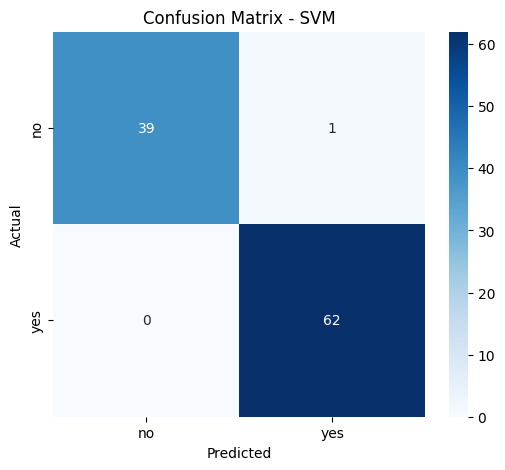



Random Forest
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

          no       1.00      1.00      1.00        40
         yes       1.00      1.00      1.00        62

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



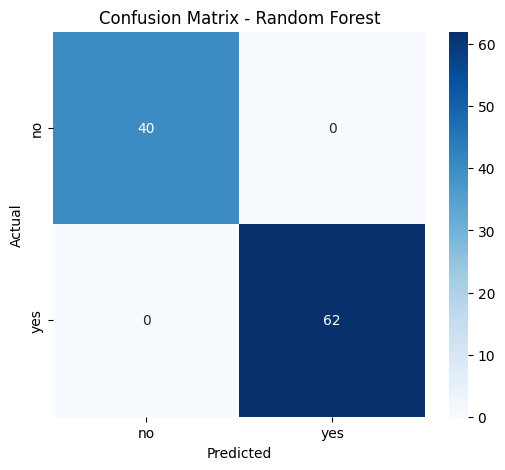



KNN
Accuracy: 0.8921568627450981

Classification Report
              precision    recall  f1-score   support

          no       0.94      0.78      0.85        40
         yes       0.87      0.97      0.92        62

    accuracy                           0.89       102
   macro avg       0.90      0.87      0.88       102
weighted avg       0.90      0.89      0.89       102



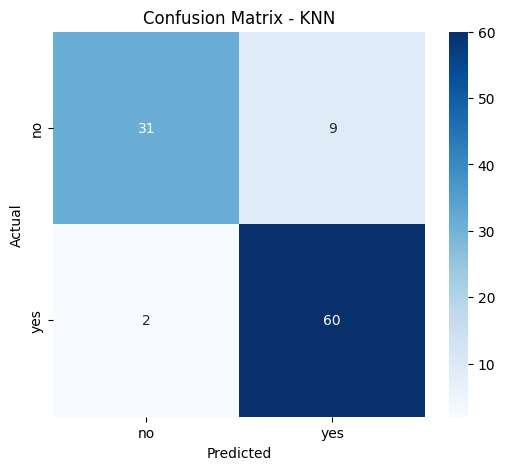

In [7]:
# =====================================================
# STEP 2: LOAD AND PREPROCESS IMAGES
# =====================================================

IMG_SIZE = 128

X = []
y = []

# Corrected classes based on os.walk output: 'no' and 'yes' folders.
classes = [
    "no",   # Label 0: No Tumor
    "yes"   # Label 1: Tumor
]

# Map class names to integer labels
class_to_label = {
    "no": 0,
    "yes": 1
}

# Define base paths where class folders might be found due to nested extraction
# 'extract_path' is 'brain_tumor_dataset'
base_paths = [
    extract_path,
    os.path.join(extract_path, extract_path) # Handles brain_tumor_dataset/brain_tumor_dataset
]

for class_name in classes:
    label = class_to_label[class_name]
    for base_p in base_paths:
        folder_path = os.path.join(
            base_p,
            class_name
        )

        # Check if the folder exists before proceeding
        if not os.path.exists(folder_path):
            print(f"Warning: Folder not found: {folder_path}. Skipping.")
            continue

        for image_name in os.listdir(folder_path): # Corrected from dataset_path to folder_path

            image_path = os.path.join(
                folder_path,
                image_name
            )

            image = cv2.imread(image_path)

            if image is None:
                print(f"Warning: Could not read image: {image_path}. Skipping.")
                continue

            # Convert to grayscale
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2GRAY
            )

            # Resize
            image = cv2.resize(
                image,
                (IMG_SIZE, IMG_SIZE)
            )

            # Normalize
            image = image / 255.0

            # =================================================
            # STEP 3: HOG FEATURE EXTRACTION
            # =================================================

            features = hog(
                image,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                feature_vector=True
            )

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Loaded {len(X)} images with {len(y)} labels.")
print("Feature Shape:", X.shape)
# =====================================================
# STEP 4: TRAIN TEST SPLIT (80:20)
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# STEP 5: FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# STEP 6: MACHINE LEARNING MODELS
# =====================================================

models = {

    "SVM":
        SVC(kernel='rbf'),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

# =====================================================
# STEP 7: TRAINING AND EVALUATION
# =====================================================

for model_name, model in models.items():

    print("\n")
    print("="*50)
    print(model_name)
    print("="*50)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print("Accuracy:", accuracy)

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=classes
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

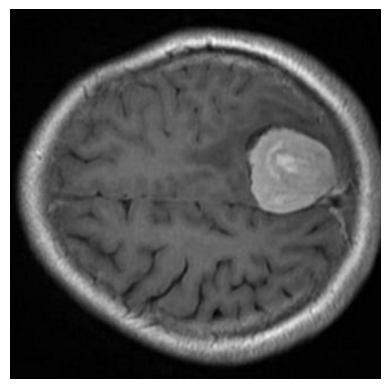


Predicted Class: Brain Tumor
🧠 Brain Tumor Detected


In [8]:
import cv2
import numpy as np
from skimage.feature import hog
import matplotlib.pyplot as plt

# ===========================
# IMAGE PATH
# ===========================

image_path = "/content/dataset-card.png"

# ===========================
# LOAD IMAGE
# ===========================

img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found. Check image path.")

else:

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # ===========================
    # PREPROCESSING
    # ===========================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (128, 128))

    gray = gray / 255.0

    # ===========================
    # HOG FEATURES
    # ===========================

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    # ===========================
    # SCALE FEATURES
    # ===========================

    features = scaler.transform([features])

    # ===========================
    # LOAD TRAINED SVM MODEL
    # ===========================

    svm_model = models["SVM"]

    # ===========================
    # PREDICTION
    # ===========================

    prediction = svm_model.predict(features)[0]

    # Corrected class names to match the binary classification model
    class_names = {
        0: "No Tumor",
        1: "Brain Tumor"
    }

    print("\nPredicted Class:", class_names[prediction])

    if prediction == 0: # 0 represents "No Tumor" based on the training data in ZPx6WN-6H3w_
        print("✅ No Brain Tumor Detected")
    else: # 1 represents "Brain Tumor"
        print("🧠 Brain Tumor Detected")